In [1]:
import torch
import models as m
import os
import json
import matplotlib.pyplot as plt
import torch.distributions as dist
import numpy as np
import math
import shutil
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:
torch.set_default_dtype(torch.float32)

if torch.cuda.is_available(): 
    device = torch.device('cuda:0')
    dtype = torch.FloatTensor
elif torch.mps.is_available():
    device = torch.device('mps')
    dtype = torch.FloatTensor
else:
    device = torch.device('cpu')
    dtype = torch.FloatTensor
    
def t(x):
    # j'avais des problèmes de type avec les long 
    return torch.as_tensor(x, dtype=torch.get_default_dtype()).to(device)

print(device)

cuda:0


In [3]:
BASE_PATH = os.getcwd()
RUNS_ROOT = os.path.join(BASE_PATH, "runs")
EXP_NAME = "comparaison"
EXP_DIR = os.path.join(RUNS_ROOT, EXP_NAME)
RUN_ID = '001'
RUN_DIR = os.path.join(EXP_DIR, RUN_ID)  
WEIGHTS_DIR = os.path.join(RUN_DIR, "weights")
LOGS_DIR = os.path.join(RUN_DIR, "logs")
VIDEO_DIR = os.path.join(RUN_DIR, 'videos')

with open(os.path.join(LOGS_DIR, 'hparams.json')) as json_data:
    hparams = json.load(json_data)
    json_data.close()
   
hparams

{'dataset': 'MNIST',
 'batch_size': 64,
 'N_epoch': 40,
 'EVAL_EVERY': 100,
 'lr': 0.0001,
 'grad_clip': 1.0,
 'sigma': {'schedule': 'lin',
  'min': 0.01,
  'max': 1.5,
  'n_sigmas': 10,
  'values': [1.5,
   1.3344444036483765,
   1.1688889265060425,
   1.003333330154419,
   0.8377777934074402,
   0.6722221970558167,
   0.5066666603088379,
   0.34111109375953674,
   0.17555555701255798,
   0.009999999776482582]},
 'device': 'cuda:0',
 'model': {'in_channel': 1,
  'base_ch': 64,
  'channel_mults': [1, 2, 2, 4, 4],
  'sigma_emb_dim': 16},
 'slurm': {'job_name': 'mnist_ncsn', 'job_id': '678573'}}

In [4]:
SIGMAS = t(hparams['sigma']['values'])

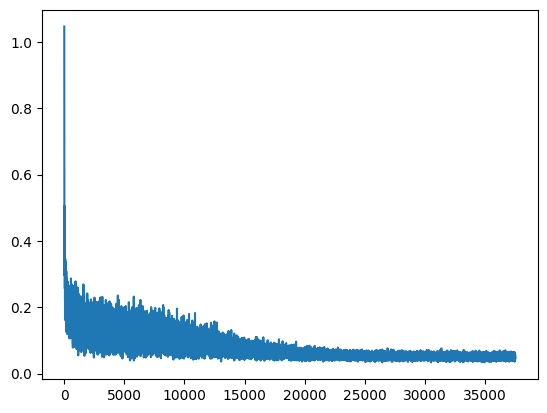

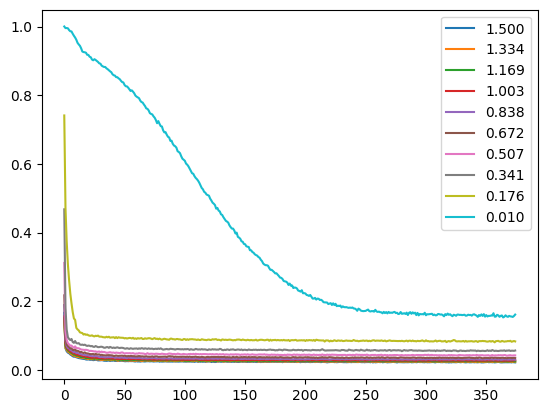

In [5]:
Loss = np.load(os.path.join(LOGS_DIR,'train_loss.npy'))
steps_eval = np.load(os.path.join(LOGS_DIR,'steps_eval.npy'))
plt.plot(Loss)
plt.show()
loss_sigma = np.load(os.path.join(LOGS_DIR,"train_loss_per_sigma.npy"))   # (n_eval, n_sigmas)
sigmas = np.load(os.path.join(LOGS_DIR,"sigmas.npy"))                    # (n_sigmas,)

for i in range(sigmas.shape[0]):
    plt.plot(loss_sigma.T[i],label= f'{sigmas[i]:.3f}')
    plt.legend()
plt.show()

In [6]:
w = torch.load(os.path.join(WEIGHTS_DIR, 'model.pt'), map_location=device, weights_only=True)
model = m.SmallUNetSigma(
    in_ch=hparams['model']['in_channel'],
    base_ch=hparams['model']['base_ch'],
    channel_mults=hparams['model']['channel_mults'],  
    emb_dim=hparams['model']['sigma_emb_dim'],
).to(device)

model.load_state_dict(w)
model = model.to(device)

total = sum(p.numel() for p in model.parameters())
print(f"{total/1e6:.2f} M params")

model.eval()

11.85 M params


SmallUNetSigma(
  (sigma_emb): SigmaEmbedding(
    (net): Sequential(
      (0): Linear(in_features=1, out_features=16, bias=True)
      (1): SiLU()
      (2): Linear(in_features=16, out_features=16, bias=True)
      (3): SiLU()
    )
  )
  (init_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (down_blocks): ModuleList(
    (0): ResBlock(
      (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
      (act1): SiLU()
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (norm2): GroupNorm(8, 64, eps=1e-05, affine=True)
      (act2): SiLU()
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (emb_proj1): Sequential(
        (0): SiLU()
        (1): Linear(in_features=16, out_features=64, bias=True)
      )
      (emb_proj2): Sequential(
        (0): SiLU()
        (1): Linear(in_features=16, out_features=64, bias=True)
      )
      (skip): Identity()
    )
    (1): ResBlock(
      (norm1): GroupN

In [7]:
# -------------------------
# Dataset MNIST [-1, 1]
# -------------------------
transform = transforms.Compose([
    transforms.Resize(28),   # MNIST 28x28 -> img_size (ex: 32)
    transforms.ToTensor(),                    # [0,1]
    transforms.Lambda(lambda x: x * 2 - 1)    # [-1,1]
])

full_data = datasets.MNIST(
    root="data/mnist",
    train=True,
    download=True,
    transform=transform,
)

print("Nb d'images :", len(full_data))
print("Classes :", full_data.classes)

100%|██████████| 9.91M/9.91M [00:00<00:00, 11.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 354kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.49MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.34MB/s]


Nb d'images : 60000
Classes : ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


Feature batch shape: torch.Size([1, 1, 28, 28])
Labels batch shape: torch.Size([1])
tensor(-1.) tensor(1.)


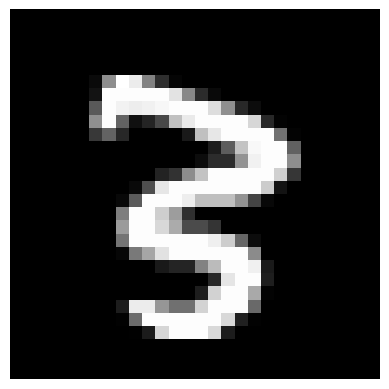

Label: 3


In [8]:

dataloader = DataLoader(full_data, batch_size=1, shuffle=True)
train_features, train_labels = next(iter(dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")

img = train_features[0].squeeze()   # (H,W)
print(img.min(), img.max())
label = train_labels[0]
plt.imshow((img + 1)/2, cmap="gray")
plt.axis('off')
plt.show()
print(f"Label: {label}")

In [9]:
if not os.path.exists(os.path.join(LOGS_DIR,"SCORE_NORM.npy")) : 
    
    NUM_BATCH = 1000
    N_mean = []
    N_var  = []

    data_iter = iter(dataloader)

    model.eval()  # pas obligatoire mais propre

    with torch.no_grad():  
        for idx in range(hparams['sigma']['n_sigmas']):
            s = SIGMAS[idx]

            # online mean/var (Welford)
            count = 0
            mean = 0.0
            M2 = 0.0

            for _ in range(NUM_BATCH):

                try:
                    x, _ = next(data_iter)
                except StopIteration:
                    data_iter = iter(dataloader)
                    x, _ = next(data_iter)

                x = x.to(device)
                B = x.size(0)

                sigma = s.expand(B, 1)
                while sigma.dim() < x.dim():
                    sigma = sigma.unsqueeze(-1)

                eps = torch.randn_like(x)
                x_noisy = x + sigma * eps

                score = model(x_noisy, sigma)

                score_sq_batch = (score ** 2).view(B, -1).sum(dim=1)

                # unbatch + update mean/var
                for val in score_sq_batch.detach().cpu().tolist():
                    count += 1
                    delta = val - mean
                    mean += delta / count
                    delta2 = val - mean
                    M2 += delta * delta2

            var = M2 / (count - 1) if count > 1 else 0.0

            N_mean.append(mean)
            N_var.append(var)

    SCORE_NORM = torch.tensor(N_mean, device=device)
    SCORE_NORM_VAR = torch.tensor(N_var, device=device)

    print("SCORE_NORM (mean):", SCORE_NORM)
    print("SCORE_NORM_VAR:", SCORE_NORM_VAR)

    CV = torch.sqrt(SCORE_NORM_VAR)/ SCORE_NORM

    print("CV", CV)
    np.save(os.path.join(LOGS_DIR,"SCORE_NORM.npy"),SCORE_NORM.cpu())
else : 
    SCORE_NORM = np.load(os.path.join(LOGS_DIR,"SCORE_NORM.npy"))

SCORE_NORM (mean): tensor([3.4460e+02, 4.3479e+02, 5.6810e+02, 7.7105e+02, 1.1049e+03, 1.7091e+03,
        2.9762e+03, 6.4200e+03, 2.3293e+04, 6.4630e+06], device='cuda:0')
SCORE_NORM_VAR: tensor([2.4405e+02, 5.0502e+02, 7.5223e+02, 1.3266e+03, 2.7311e+03, 7.3807e+03,
        2.0385e+04, 9.1065e+04, 1.2744e+06, 5.8794e+10], device='cuda:0')
CV tensor([0.0453, 0.0517, 0.0483, 0.0472, 0.0473, 0.0503, 0.0480, 0.0470, 0.0485,
        0.0375], device='cuda:0')


In [10]:
# pas de gradient ici pour ALD 
def make_score_from_model(model, sigma_scalar, eps_loss = False):
    sigma_scalar = float(sigma_scalar)
    
    @torch.no_grad()
    def score(x):
        # x: (B, C, H, W)
        B = x.shape[0]
        sigma = x.new_full((B, 1), sigma_scalar).to(device)   # (B,1) 
        return model(x, sigma)
     
    return score

In [11]:
estimated_distribution_scores = [make_score_from_model(model,noise) for noise in list(SIGMAS)]

In [12]:
sigma_prior = SIGMAS.max().item()
prior_normal = dist.Normal(
    loc=torch.tensor(0.0, device=device),
    scale=torch.tensor(sigma_prior, device=device),
)
prior_unif = dist.Uniform(-1,1)

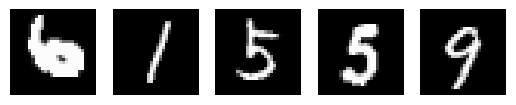

In [13]:
# Petit batch de vraies images pour visualiser
u = []
for x in range(5):
    v,_ = next(iter(dataloader))
    u.append(v)
        
z = torch.concat(u).to(device)

for i in range(z.shape[0]) : 
    plt.subplot(1,z.shape[0],i+1)
    img = z[i].clone().squeeze().detach().cpu()   # (H,W) pour MNIST
    img_norm = (img - img.min()) / (img.max() - img.min() + 1e-8)
    plt.imshow(img_norm, cmap="gray")
    plt.axis('off')
plt.show()

In [14]:
def annealded_langevin_sampler_snr(prior, noisy_distrib_scores, noise_factor,
                                   SNR, norm, T, n_chain, save_dir=None):
    
    # on n'utilise plus z pour init, mais je laisse la structure
    u = []
    for x in range(n_chain):
        v,_ = next(iter(dataloader))
        u.append(v)
        
    # z = torch.concat(u).to(device)  # pas utilisé dans la suite

    C = hparams['model']['in_channel']   # 1 pour MNIST
    H = 28
    W = 28
    X = prior.sample((n_chain, C, H, W)).to(device)

    D = H * W
    PLOT_STEP_EVERY = np.inf         
    IDX_TO_TRACK = [u for u in range(n_chain)]   # on suit toutes les chaînes

    if save_dir is not None:
        if os.path.exists(save_dir):
            shutil.rmtree(save_dir)
        os.makedirs(save_dir)

    frame = 0  

    for i in range(len(noisy_distrib_scores)):
        tau = 2 * D * SNR / norm[i]
        noise_std = math.sqrt(2 * tau)

        for step in range(T):

            X = X + tau * noisy_distrib_scores[i](X) + noise_std * torch.randn_like(X)

            if ((step + 1) % T == 0 ) or ((step +1) % PLOT_STEP_EVERY == 0) or step == 0 :
                plt.figure(figsize=(3*len(IDX_TO_TRACK), 3))
                for y,z_idx in enumerate(IDX_TO_TRACK) : 
                    plt.subplot(1,len(IDX_TO_TRACK),y+1)
                    img = X[z_idx].clone().squeeze().detach().cpu()
                    img_norm = (img - img.min()) / (img.max() - img.min() + 1e-8)
                    # gris si 2D, sinon RGB
                    if img_norm.ndim == 2:
                        plt.imshow(img_norm, cmap="gray")
                    else:
                        plt.imshow(img_norm.permute(1,2,0))
                    plt.axis('off')
                plt.suptitle(
                    f"sigma={noise_factor[i]:.3f} | "
                    f"SNR={SNR:.2e} | "
                    f"noise_std={noise_std:.2e} | "
                    f"step={step}"
                )

                if save_dir is not None:
                    fname = os.path.join(save_dir, f"frame_{frame:05d}.png")
                    plt.savefig(fname, dpi=150, bbox_inches='tight', pad_inches=0)
                    plt.close()
                else:
                    plt.show()

                frame += 1

    # dernière phase sans bruit
    for step in range(T):

        X = X + tau * noisy_distrib_scores[i](X) 

        if ((step + 1) % T == 0 ) or ((step +1) % PLOT_STEP_EVERY == 0) or step == 0 :
            plt.figure(figsize=(3*len(IDX_TO_TRACK), 3))
            for y,z_idx in enumerate(IDX_TO_TRACK) : 
                plt.subplot(1,len(IDX_TO_TRACK),y+1)
                img = X[z_idx].clone().squeeze().detach().cpu()
                img_norm = (img - img.min()) / (img.max() - img.min() + 1e-8)
                if img_norm.ndim == 2:
                    plt.imshow(img_norm, cmap="gray")
                else:
                    plt.imshow(img_norm.permute(1,2,0))
                plt.axis('off')
            plt.suptitle(
                f"sigma={noise_factor[i]:.3f} | "
                f"SNR={SNR:.2e} | "
                f"noise_std={noise_std:.2e} | "
                f"step={step}"
            )

            if save_dir is not None:
                fname = os.path.join(save_dir, f"frame_{frame:05d}.png")
                plt.savefig(fname, dpi=150, bbox_inches='tight', pad_inches=0)
                plt.close()
            else:
                plt.show()

            frame += 1
    
    if save_dir is not None:
        os.system(f"./make_ald_video.sh {save_dir} {SNR} {T}")

    return X

In [15]:
OUTDIR = os.path.join(VIDEO_DIR,'out/')

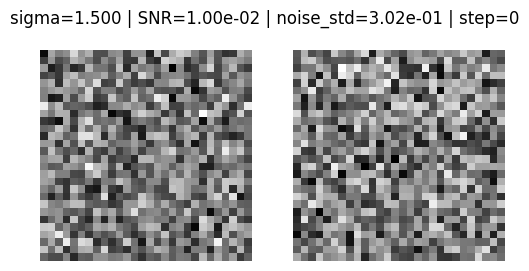

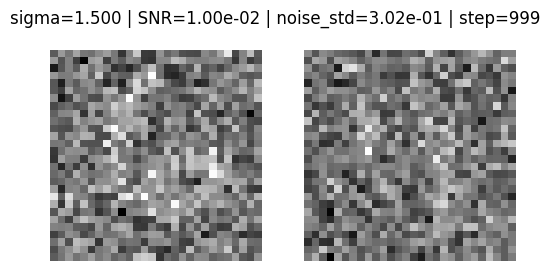

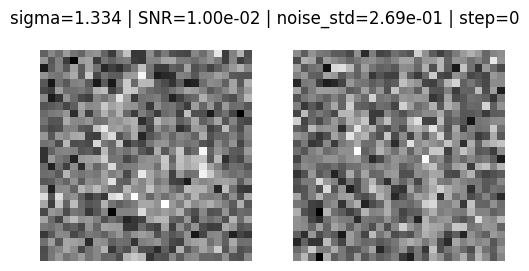

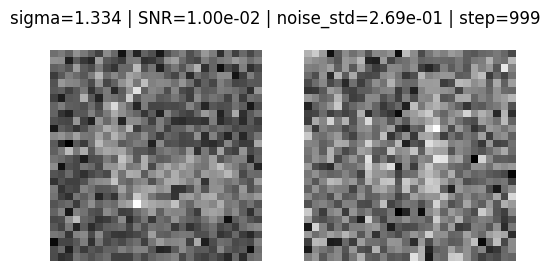

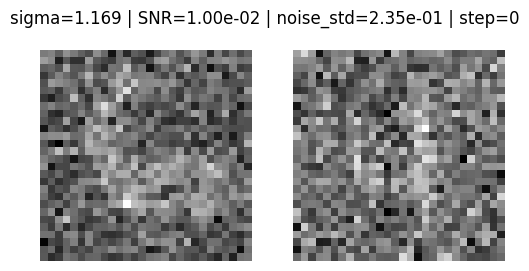

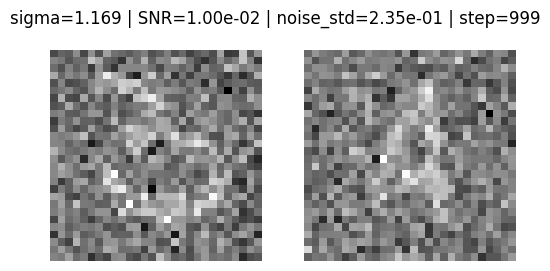

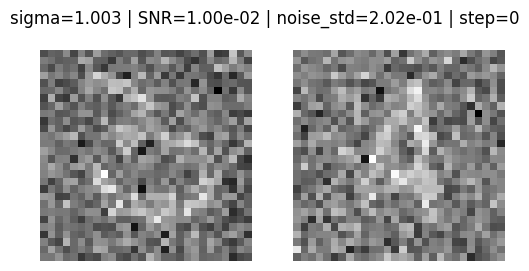

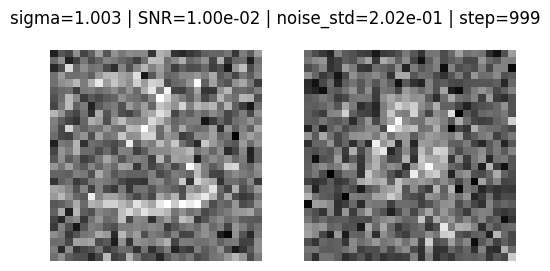

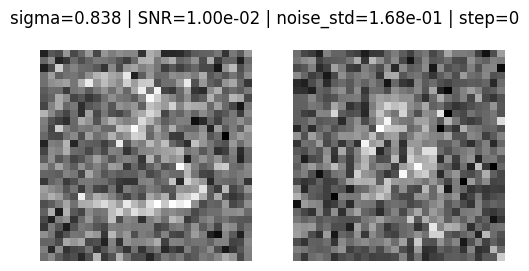

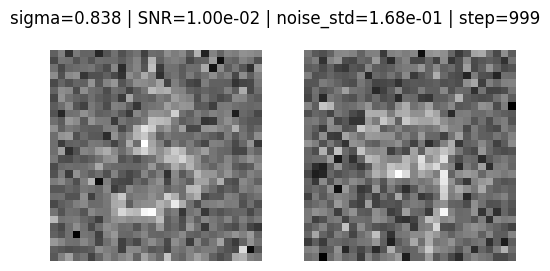

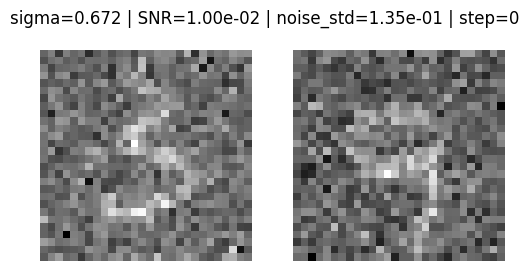

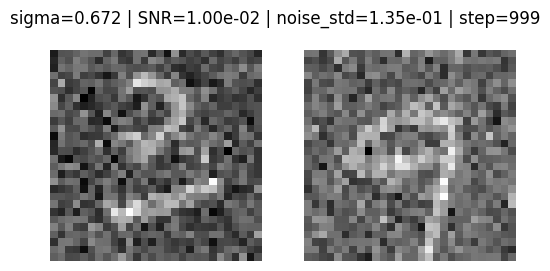

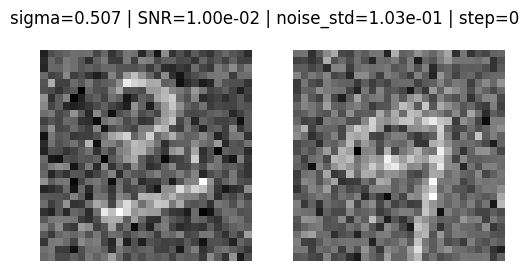

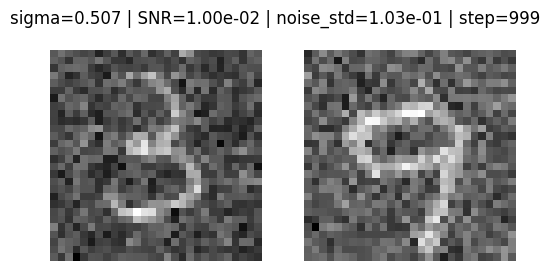

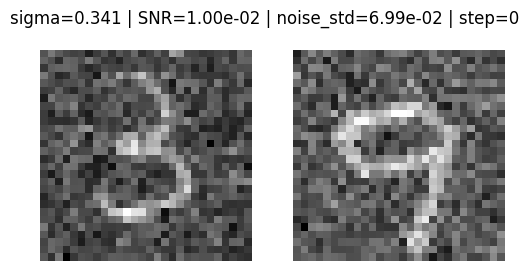

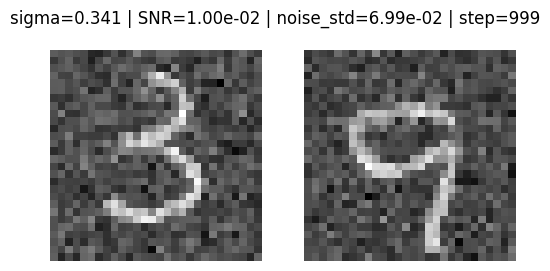

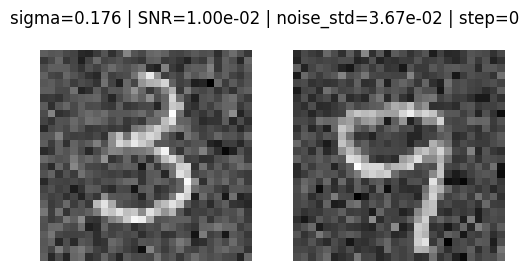

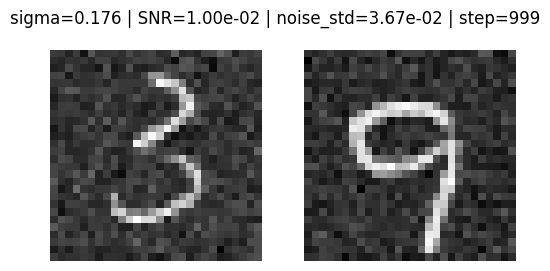

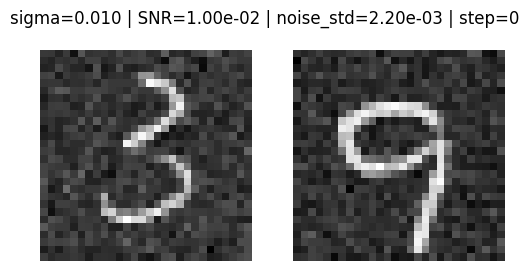

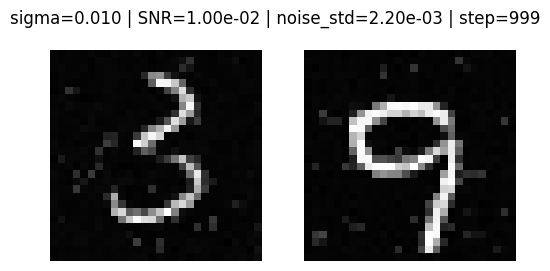

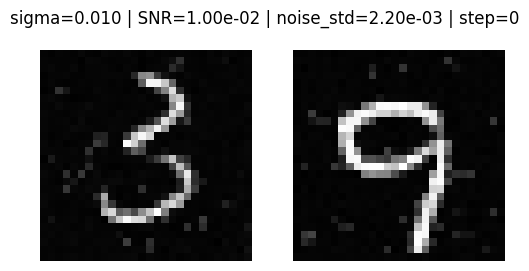

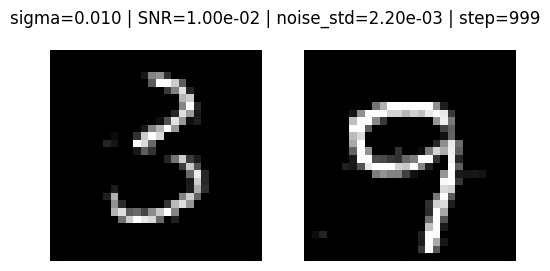

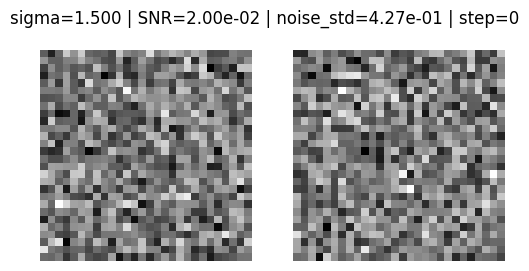

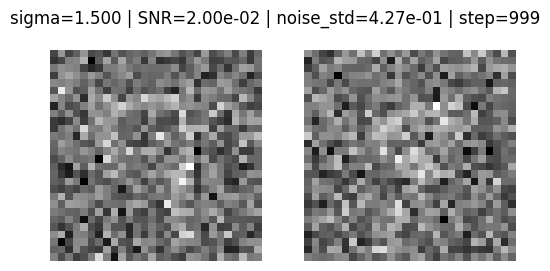

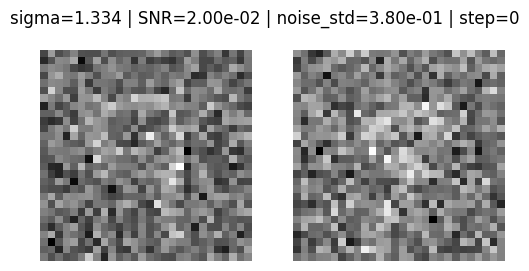

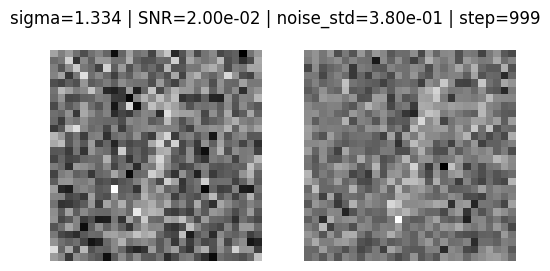

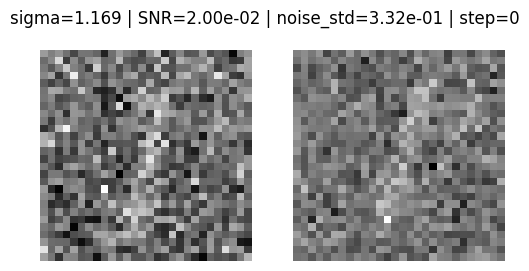

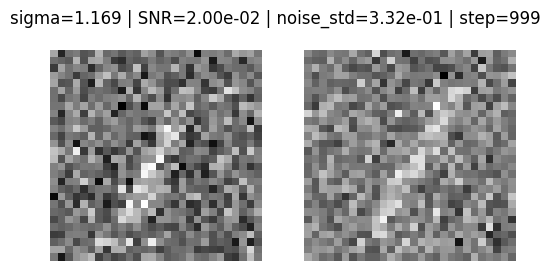

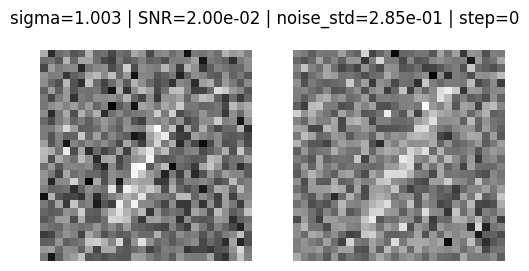

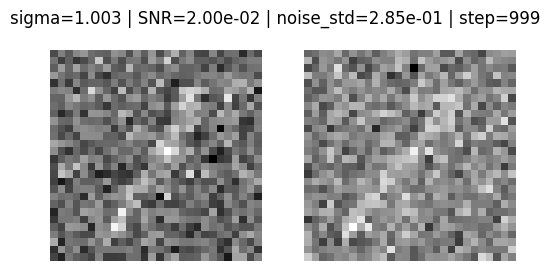

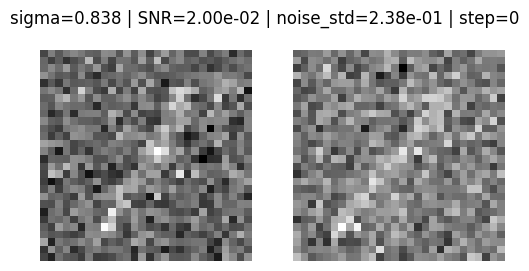

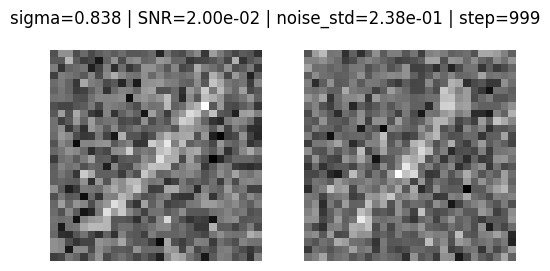

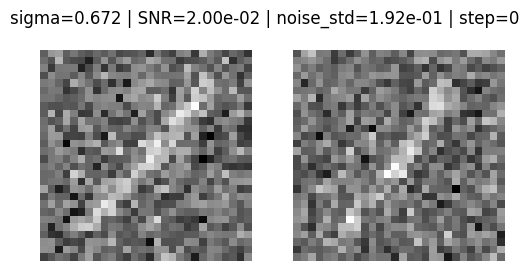

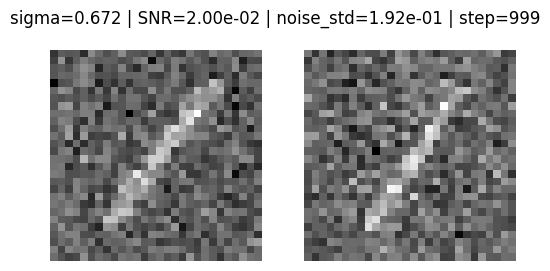

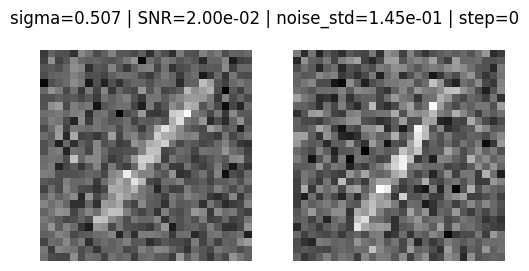

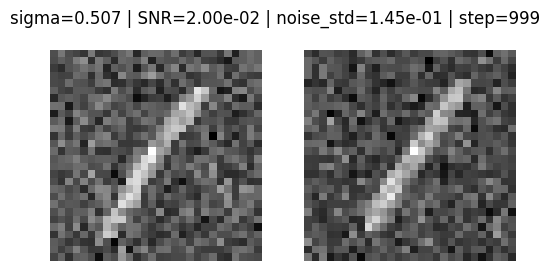

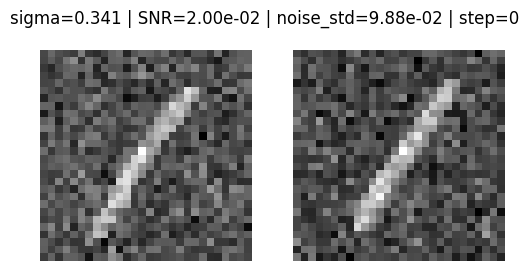

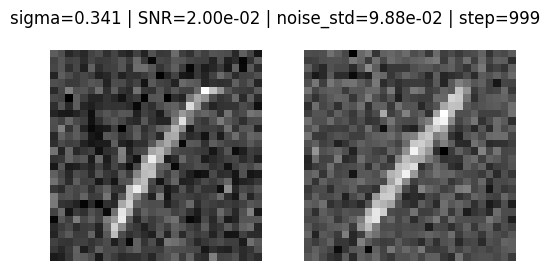

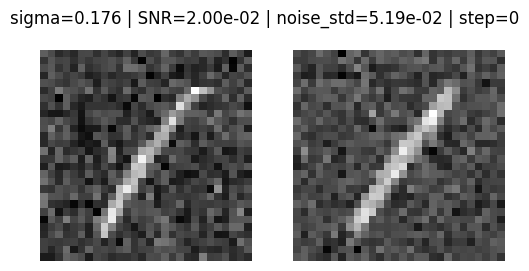

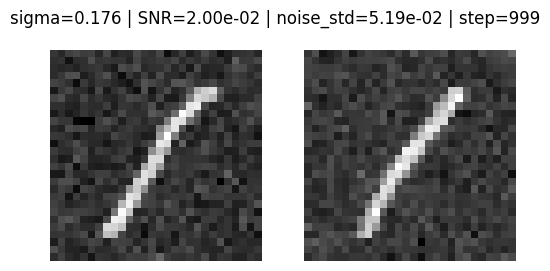

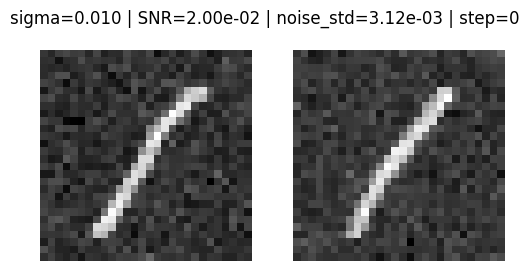

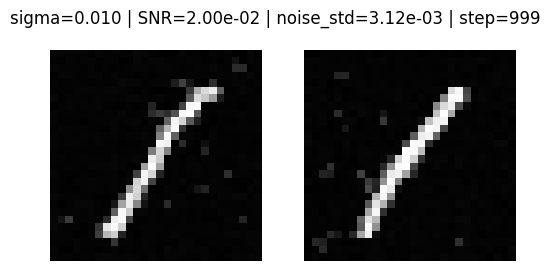

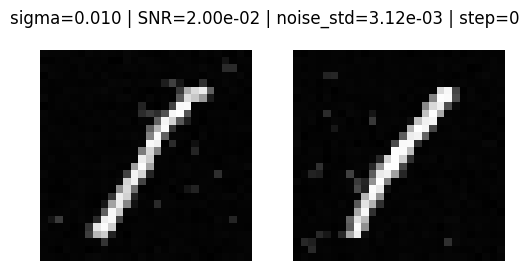

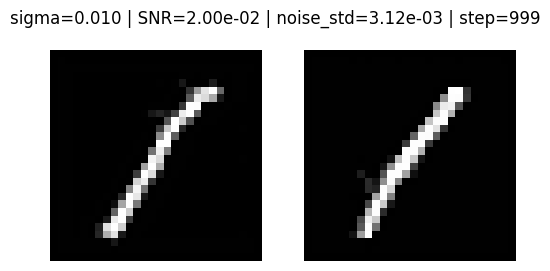

In [ ]:
for SNR in [0.01,0.02]:
    ALD_estimated_score_snr = annealded_langevin_sampler_snr(
        prior_unif,
        estimated_distribution_scores,
        SIGMAS,
        SNR,
        SCORE_NORM,
        T = 1000,
        n_chain=2,
        save_dir=None
        
    )